# 03 — Evaluation & Confusion Matrix

**Purpose:** Evaluate a saved model checkpoint with per-image results and a confusion matrix.

Logic lives in `src/evaluation_script.py` and `src/confusion_matrix.py`.  

**Prerequisite:** Run notebook 02 first to produce `models/age_classifier.pth`.

## Setup

In [1]:
!pip install -q torch torchvision scikit-learn seaborn matplotlib

import os, sys

try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/AuraVision'
except ImportError:
    PROJECT_ROOT = os.path.abspath('..')

os.chdir(PROJECT_ROOT)
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'src'))
print('Working directory:', os.getcwd())

Working directory: c:\Users\Asus\Downloads\AuraVision\AuraVision


## Per-Image Evaluation

Prints a table showing filename, true class, predicted class, confidence, and ✓/✗.  
A failure summary is printed at the end.

In [5]:
from evaluation_script import analyze_individual_files

ORIGINAL_MODEL_PATH = "models/age_classifier.pth"
FINETUNED_MODEL_PATH = "models/age_classifier_finetuned.pth"



### Original Model result

In [4]:
analyze_individual_files(ORIGINAL_MODEL_PATH)



Analyzing 256 test images...

FILENAME                            | TRUE         | PREDICTION   | CONFIDENCE
--------------------------------------------------------------------------------
Airport_terminal_crowd_11.jpg       | Adults       | Adults       | 96.59% ✓
Airport_terminal_crowd_20.jpg       | Adults       | Adults       | 99.44% ✓
Airport_terminal_crowd_22.jpg       | Adults       | Adults       | 99.98% ✓
Airport_terminal_crowd_23.jpg       | Adults       | Adults       | 99.99% ✓
Airport_terminal_crowd_29.jpg       | Adults       | Adults       | 99.53% ✓
Airport_terminal_crowd_3.jpg        | Adults       | Adults       | 99.97% ✓
Airport_terminal_crowd_31.jpg       | Adults       | Adults       | 99.99% ✓
Airport_terminal_crowd_5.jpg        | Adults       | Adults       | 88.85% ✓
Airport_terminal_crowd_6.jpg        | Adults       | Adults       | 99.62% ✓
Busy_food_court_0.jpg               | Adults       | Adults       | 98.15% ✓
Busy_food_court_15.jpg              | Ad

### Finetuned Model result

In [6]:
analyze_individual_files(FINETUNED_MODEL_PATH)

Analyzing 256 test images...

FILENAME                            | TRUE         | PREDICTION   | CONFIDENCE
--------------------------------------------------------------------------------
Airport_terminal_crowd_11.jpg       | Adults       | Adults       | 87.00% ✓
Airport_terminal_crowd_20.jpg       | Adults       | Adults       | 79.99% ✓
Airport_terminal_crowd_22.jpg       | Adults       | Adults       | 98.71% ✓
Airport_terminal_crowd_23.jpg       | Adults       | Adults       | 97.89% ✓
Airport_terminal_crowd_29.jpg       | Adults       | Adults       | 90.36% ✓
Airport_terminal_crowd_3.jpg        | Adults       | Adults       | 99.03% ✓
Airport_terminal_crowd_31.jpg       | Adults       | Adults       | 98.95% ✓
Airport_terminal_crowd_5.jpg        | Adults       | Adults       | 68.62% ✓
Airport_terminal_crowd_6.jpg        | Adults       | Adults       | 90.39% ✓
Busy_food_court_0.jpg               | Adults       | Adults       | 78.66% ✓
Busy_food_court_15.jpg              | Ad

## Confusion Matrix

Plots a heatmap and prints a full sklearn classification report.

## Original Model

Gathering predictions...


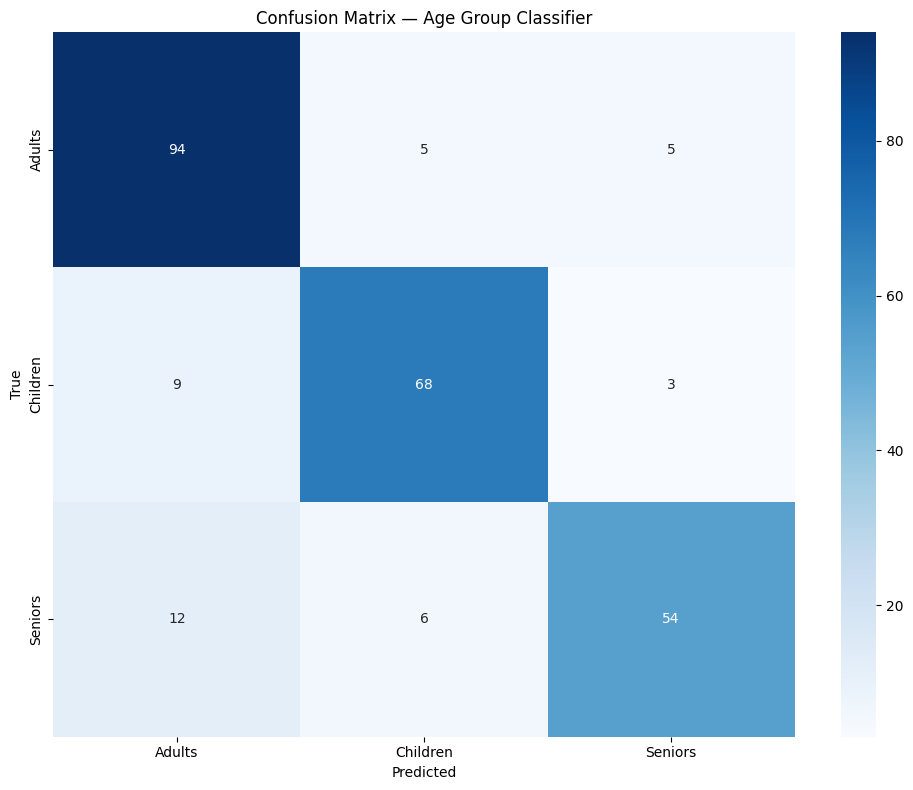


Detailed Classification Report:
              precision    recall  f1-score   support

      Adults       0.82      0.90      0.86       104
    Children       0.86      0.85      0.86        80
     Seniors       0.87      0.75      0.81        72

    accuracy                           0.84       256
   macro avg       0.85      0.83      0.84       256
weighted avg       0.85      0.84      0.84       256



In [7]:
from confusion_matrix import generate_matrix
generate_matrix(ORIGINAL_MODEL_PATH)


## Finetuned model

Gathering predictions...


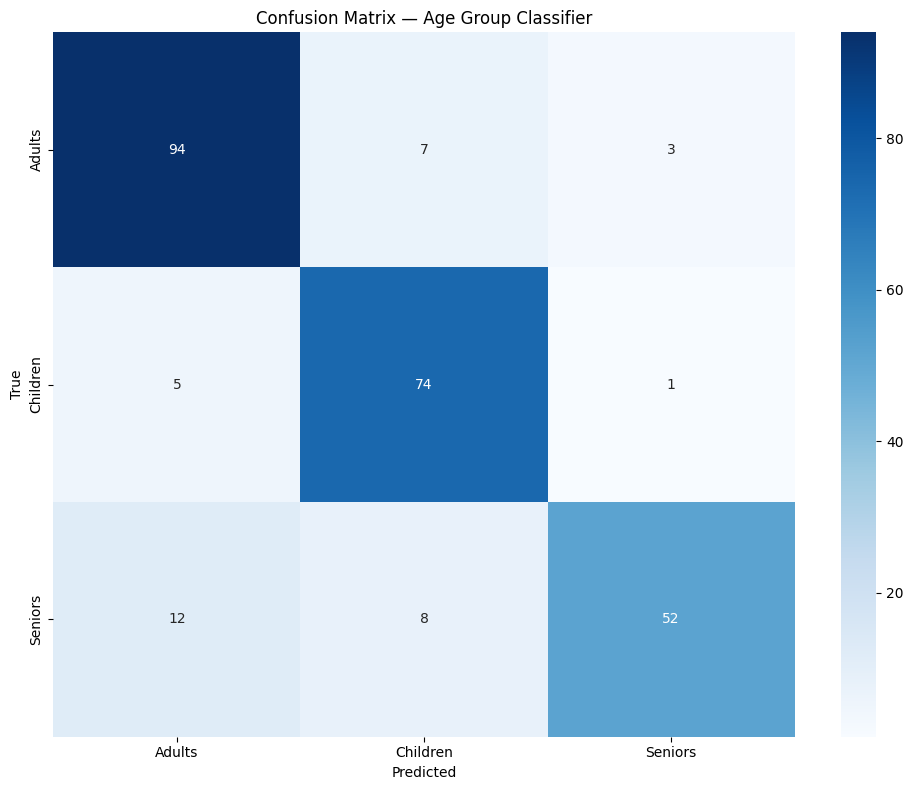


Detailed Classification Report:
              precision    recall  f1-score   support

      Adults       0.85      0.90      0.87       104
    Children       0.83      0.93      0.88        80
     Seniors       0.93      0.72      0.81        72

    accuracy                           0.86       256
   macro avg       0.87      0.85      0.85       256
weighted avg       0.87      0.86      0.86       256



In [8]:
generate_matrix(FINETUNED_MODEL_PATH)